In [1]:
%load_ext autoreload
%autoreload 2

**I302 - Aprendizaje Automático y Aprendizaje Profundo**

<h1 style="text-align: center;">Proyecto Final: <strong>Predicción de Etapas del Sueño sobre Señales Fisiológicas con RNNs</strong></h1>

*Agustín A. Pereyra & Agustín Patruno*

---

In [2]:
from src.data import EDA, STAGES_LABELS
import src.plots as plots
import src.metrics as metrics

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import json

# **Análisis Exploratorio de Datos** (EDA)

## El Dataset

Se compone de datos de 47 pacientes (BidslabXX) sanos con grabaciones de entre 3 a 7 noches de (1) la frecuencia cardiaca instantánea (IHR) y (2) 3 ejes de acelerometría medidos por un Apple Watch con un total de 253 noches de datos. Cada época (lapsos de 30 segundos) vienen etiquetados por un experto (*expert_label*) y el dispotitivo "Dreem 2 Headband" (*dreem_label*), un monitor de sueño portátil.

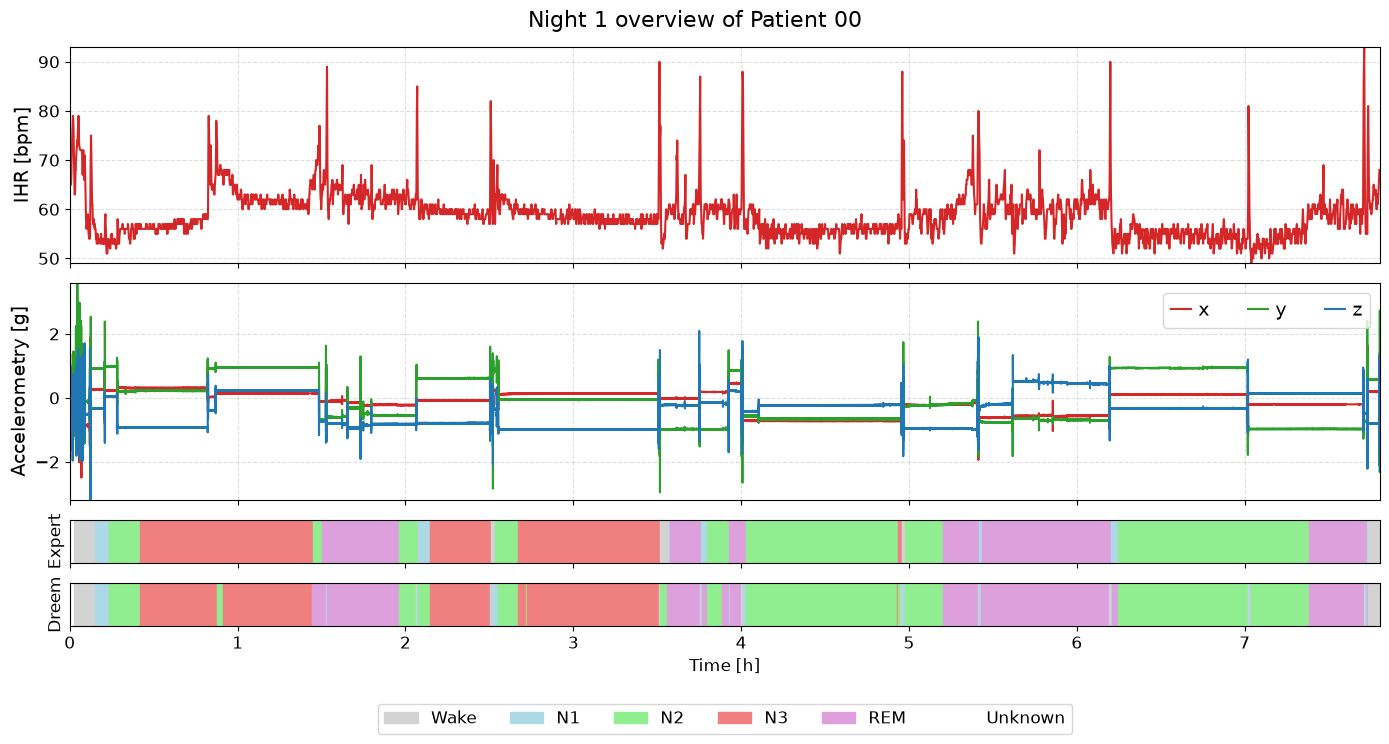

In [4]:
patient, night = 0, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

Encontramos noches con datos inconsistentes y/o mal condicionados como por ejemplo el siguiente en el que los timestamps indican duración de $\sim30$ horas, por lo que debimos realizar el descarte de noches.

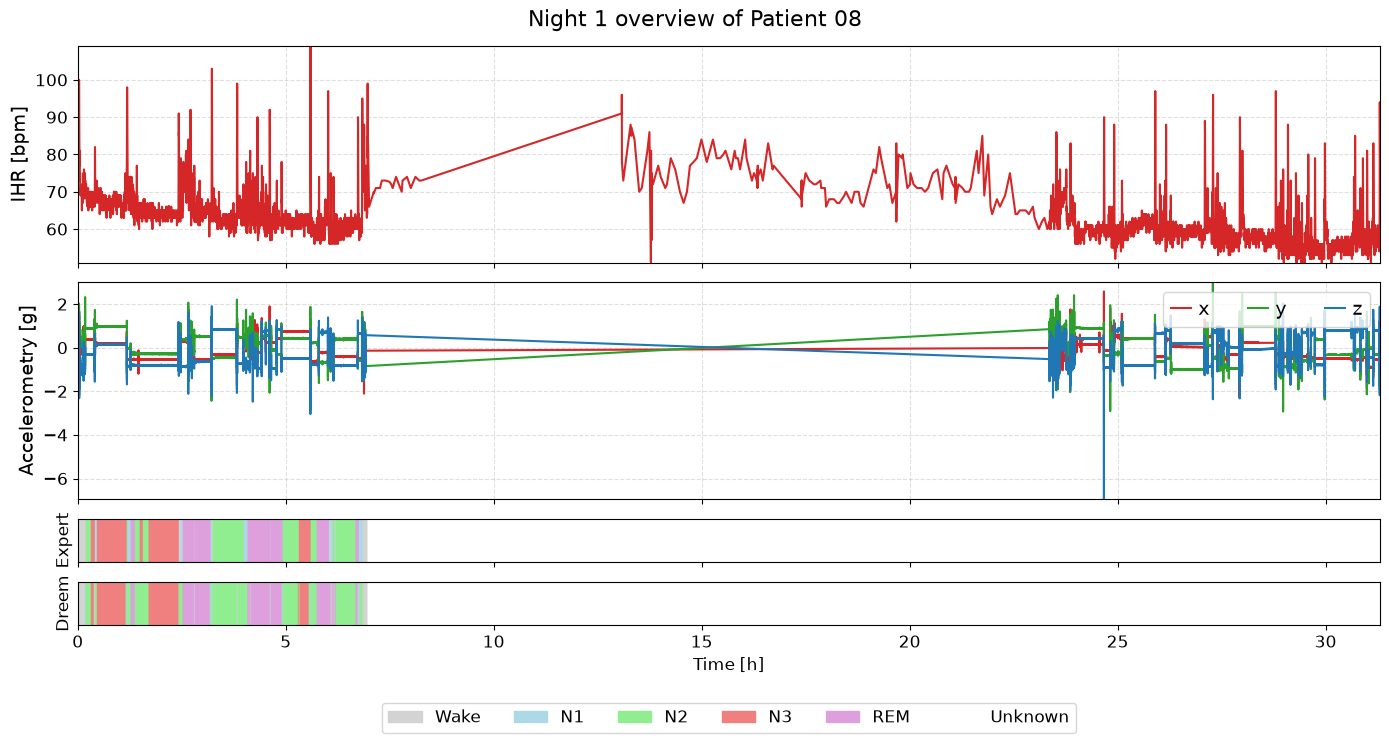

In [5]:
patient, night = 8, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

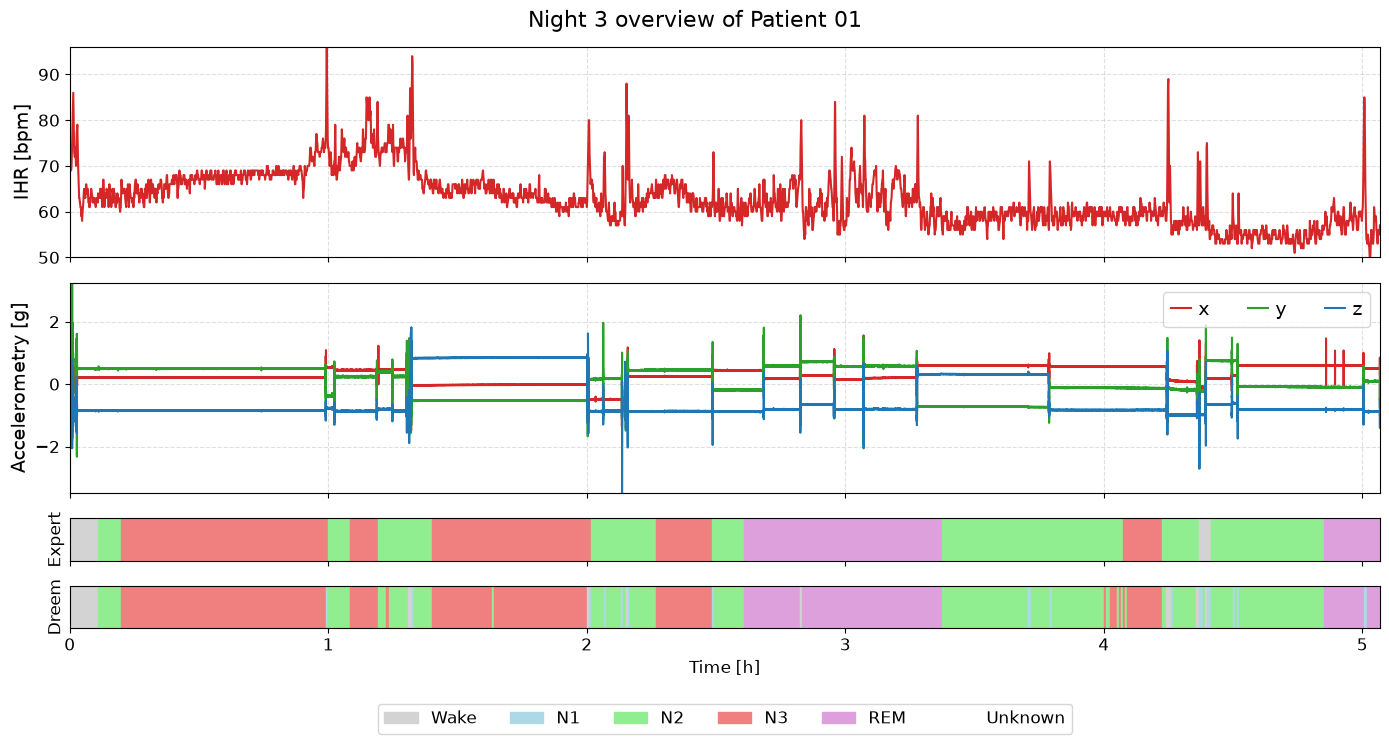

In [6]:
patient, night = 1, 3
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

`EDA.quality_report()` recorre las 253 noches y, para cada una, calcula:

- **Gaps temporales** (>60s) en `hr.csv` y `motion.csv`.
- **Cobertura de labels** (`label_coverage_frac`): qué fracción de la duración total del registro está cubierta por las épocas etiquetadas (`n_label_epochs * 30s`).
- **Acelerometría inválida**: fracción de muestras donde $|\sqrt{x^2+y^2+z^2} - 1| > 0.5g$.
- **IHR inválido**: muestras con `hr <= 0` o `hr > 200` bpm (descartando los bordes de la grabación).

A partir de estas métricas calculamos, para cada noche, la **ventana válida**: la intersección entre la ventana etiquetada (`[recStart, recStart + label_span_s]`, con `label_span_s = n_label_epochs * 30`) y el rango real de señal de `hr.csv` (`[hr_start, hr_end]`):

- **`leading_trunc_s`**: cuánto empieza después la señal respecto al inicio de las labels (`max(0, hr_start - recStart)`).
- **`trailing_trunc_s`**: cuánto termina antes la señal respecto al fin de las labels (`max(0, label_end - hr_end)`), como en el ejemplo de Patient 32 - Night 7 de arriba.
- **`internal_gap_s`**: suma de los gaps de `hr.csv` que caen *dentro* de la ventana válida (no en los extremos), es decir, discontinuidades en medio de la secuencia.

**Criterio de descarte**: distinguimos dos tipos de problema:

1. **Diferencias en los extremos** (`leading_trunc_s`, `trailing_trunc_s`): si son menores a `EDGE_TRUNC_THRESHOLD_S = 1h`, no son motivo de descarte — al construir el dataset simplemente se trunca la ventana etiquetada a la región con señal válida (como en Patient 32 - Night 7, donde sólo se pierden los últimos ~18min). Si superan ese umbral, la noche se descarta.
2. **Gaps internos** (`internal_gap_s`): rompen la continuidad de la secuencia, por lo que el criterio es estricto: se descarta si `internal_gap_s > INTERNAL_GAP_THRESHOLD_S = 10min`.

Ambos umbrales son constantes configurables en `src/data.py`. Se descartan las noches que cumplen alguna de las tres condiciones; la lista, con los tres valores por noche, se guarda en `analysis/discarded_nights.json`.

In [7]:
df_quality = EDA.quality_report()

Paciente 68 - Noche 4: 100%|██████████| 253/253 [03:51<00:00,  1.09it/s]


In [8]:
from src.data import INTERNAL_GAP_THRESHOLD_S, EDGE_TRUNC_THRESHOLD_S

discarded_nights = EDA.discard_nights(df_quality, INTERNAL_GAP_THRESHOLD_S, EDGE_TRUNC_THRESHOLD_S)

with open('analysis/discarded_nights.json', 'w', encoding='utf-8') as f:
    json.dump({
        'criterion': 'internal_gap_s > internal_gap_threshold OR leading_trunc_s/trailing_trunc_s > edge_trunc_threshold',
        'internal_gap_threshold_s': INTERNAL_GAP_THRESHOLD_S,
        'edge_trunc_threshold_s': EDGE_TRUNC_THRESHOLD_S,
        'description': (
            'Ventana valida = interseccion entre la ventana etiquetada '
            '[recStart, recStart + label_span_s] y el rango de senial de hr.csv. '
            'leading_trunc_s/trailing_trunc_s son las diferencias entre labels y '
            'senial al inicio/fin (si son menores al umbral, se truncan al construir '
            'el dataset en vez de descartar la noche). internal_gap_s es la suma de '
            'gaps de hr.csv (>60s) dentro de la ventana valida.'
        ),
        'n_total_nights': len(df_quality),
        'n_discarded': len(discarded_nights),
        'discarded': [
            {
                'patient': int(d['patient']),
                'night': int(d['night']),
                'internal_gap_s': float(d['internal_gap_s']),
                'leading_trunc_s': float(d['leading_trunc_s']),
                'trailing_trunc_s': float(d['trailing_trunc_s']),
            }
            for d in discarded_nights
        ],
    }, f, indent=2)

print(f'Noches descartadas: {len(discarded_nights)} / {len(df_quality)} ({100*len(discarded_nights)/len(df_quality):.1f}%)')

Noches descartadas: 32 / 253 (12.6%)


### Distribución de Etapas de Sueño

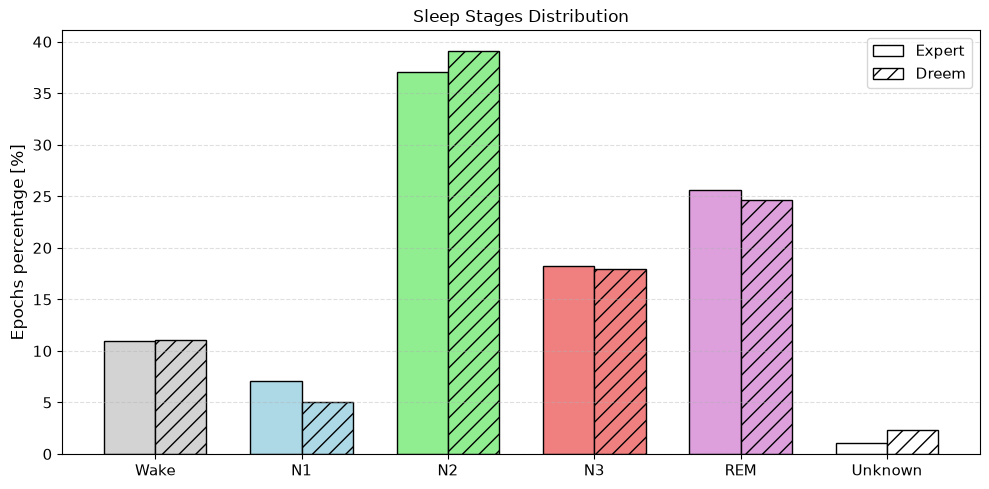

In [9]:
distributions = EDA.class_distribution()
plots.class_distribution(distributions)

### Labels "Expert" vs "Dreem"

**Cohen's Kappa** mide el *acuerdo* entre dos clasificadores (en este caso, el etiquetado del experto y el del dispositivo Dreem) corrigiendo por el acuerdo que se esperaría por azar dado el desbalance de clases (Cohen, 1960). Se define como:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde:
- $p_o$ es la **proporción observada de acuerdo** (accuracy): fracción de epochs donde ambos etiquetados coinciden.
- $p_e$ es la **proporción de acuerdo esperada por azar**, calculada a partir de las distribuciones marginales de cada clasificador: $p_e = \sum_k \frac{n_{k\cdot} \cdot n_{\cdot k}}{n^2}$, con $n_{k\cdot}$ y $n_{\cdot k}$ las marginales de fila/columna de la matriz de confusión y $n$ el total de epochs.

**Valores que puede tomar:**
- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo observado es igual al esperado por azar (no hay acuerdo más allá del azar).
- $\kappa < 0$: el acuerdo es peor que el azar (desacuerdo sistemático).
- En general $-1 \le \kappa \le 1$.

**Interpretación habitual [(Landis & Koch, 1977)](http://doi.org/10.2307/2529310):** $<0$ sin acuerdo, $0$–$0.2$ leve, $0.2$–$0.4$ aceptable, $0.4$–$0.6$ moderado, $0.6$–$0.8$ sustancial, $0.8$–$1$ casi perfecto.

Además del valor global, se calcula $\kappa$ **por clase** mediante un esquema one-vs-rest: para cada etapa $k$ se binariza el problema (¿es clase $k$ o no?) y se computa $\kappa$ sobre esa matriz de confusión 2x2, lo que permite identificar en qué etapas específicas el experto y Dreem difieren más.

In [10]:
expert, dreem = EDA.all_labels()
kappa_global = metrics.cohen_kappa(expert, dreem)
kappa_per_class = metrics.cohen_kappa_per_class(expert, dreem)

labels = ['K (global)'] + [f'K ({stage})' for stage in STAGES_LABELS.values()]
label_width = max(len(l) for l in labels)

print(f'{labels[0]:<{label_width}} = {kappa_global:.4f}')
for label, k in zip(labels[1:], kappa_per_class):
    print(f'{label:<{label_width}} = {k:.4f}')

K (global) = 0.0585
K (Wake)   = 0.0096
K (N1)     = 0.0169
K (N2)     = 0.0530
K (N3)     = 0.1228
K (REM)    = 0.0554
K (Unkown) = 0.0297


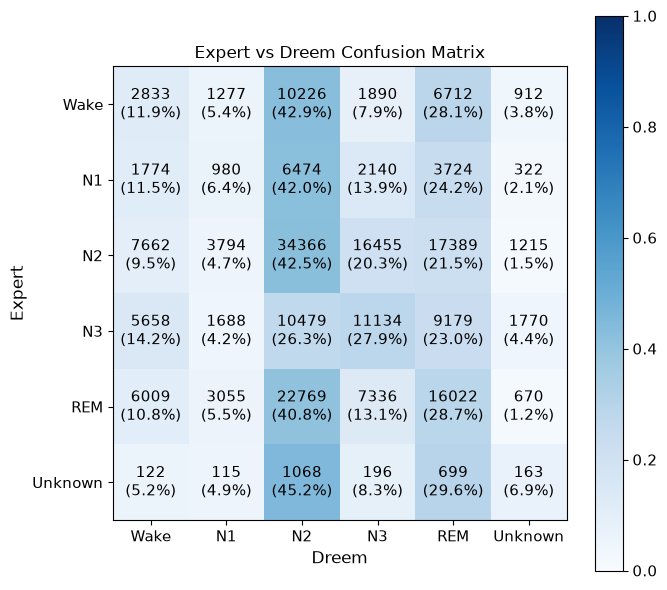

In [11]:
cm = metrics.confusion_matrix(expert, dreem)
plots.confusion_matrix(cm)

## **Baseline**: XGBoost + Feature Extraction

## 2 Enfoques Posibles para definir la **Secuencia**

Para procesar la secuencia de pasos temporales, debemos definir cuál es este paso temporal.

- **Intra-epoch**: el paso temporal es cada muestra dentro de una época (lapso de 30 segundos). Cada época se clasifica de forma independiente.
- **Inter-epoch**: el paso temporal es cada época completa. El modelo mira a lo largo de la noche.